In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df=pd.read_excel('/content/Telco_customer_churn.xlsx')
df.sample(4)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2232,9094-AZPHK,1,United States,California,San Bernardino,92405,"34.142747, -117.300864",34.142747,-117.300864,Female,...,Month-to-month,Yes,Electronic check,100.15,1415,No,0,65,2565,NaN
6872,8071-SBTRN,1,United States,California,Canoga Park,91304,"34.224377, -118.632656",34.224377,-118.632656,Female,...,Two year,Yes,Mailed check,111.15,7737.55,No,0,62,4240,NaN
856,3318-OSATS,1,United States,California,Sierra City,96125,"39.600599, -120.636358",39.600599,-120.636358,Male,...,Month-to-month,Yes,Electronic check,95.45,3474.05,Yes,1,91,2080,Don't know
5613,9402-ROUMJ,1,United States,California,La Habra,90631,"33.940619, -117.9513",33.940619,-117.951300,Female,...,One year,Yes,Bank transfer (automatic),100.25,6689,No,0,64,5588,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.shape

(7043, 33)

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


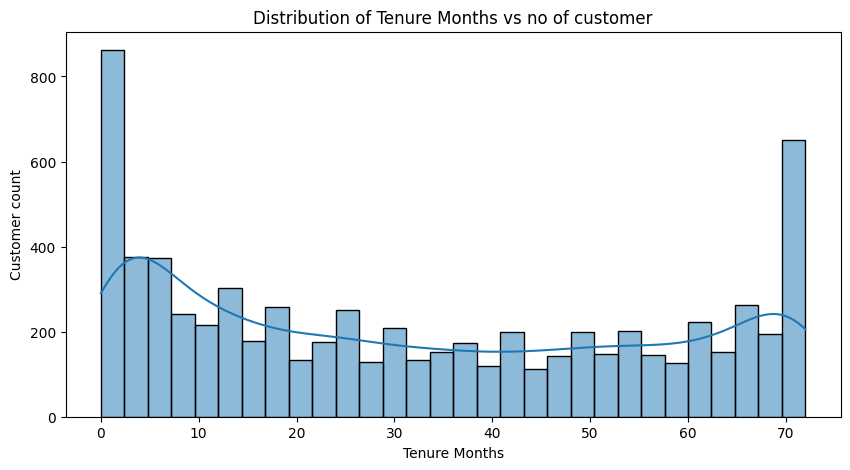

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [7]:
df['Tenure Months'].max(),df['Tenure Months'].min()

(72, 0)

In [8]:
(72-0)/30

2.4

<Axes: xlabel='Tenure Months', ylabel='Count'>

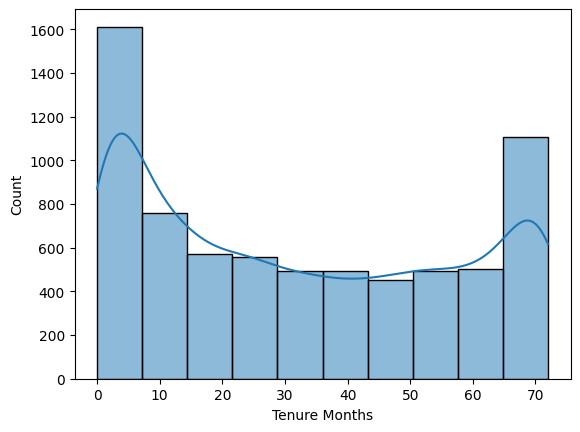

In [9]:
sns.histplot(df['Tenure Months'],bins=10,kde=True)

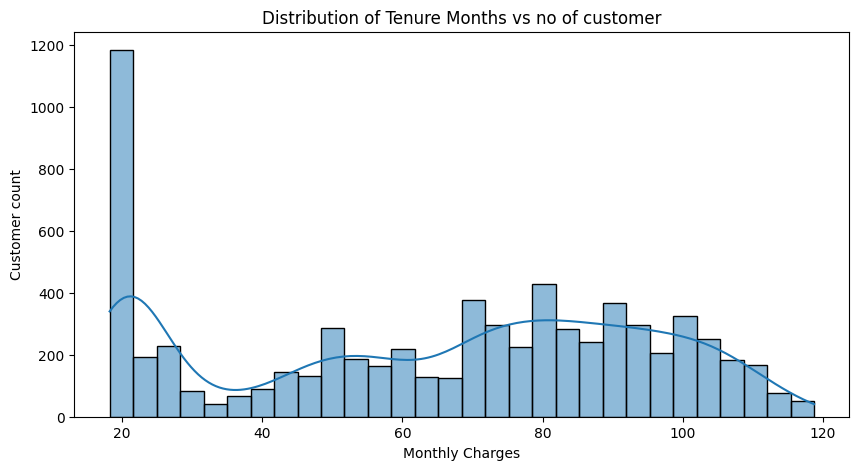

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [11]:
df['Monthly Charges'].max(),df['Monthly Charges'].min()

(118.75, 18.25)

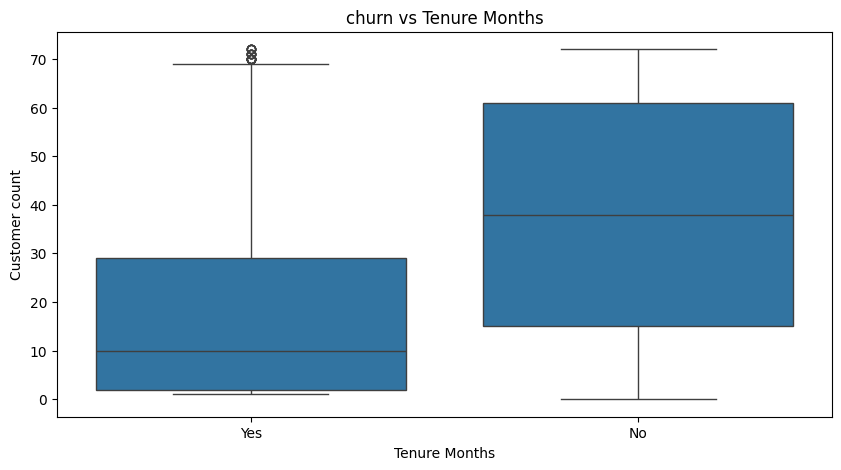

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Tenure Months',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs Tenure Months')
plt.show()

after 10 month the churn but person availing for 32 months are continuing to avaling it

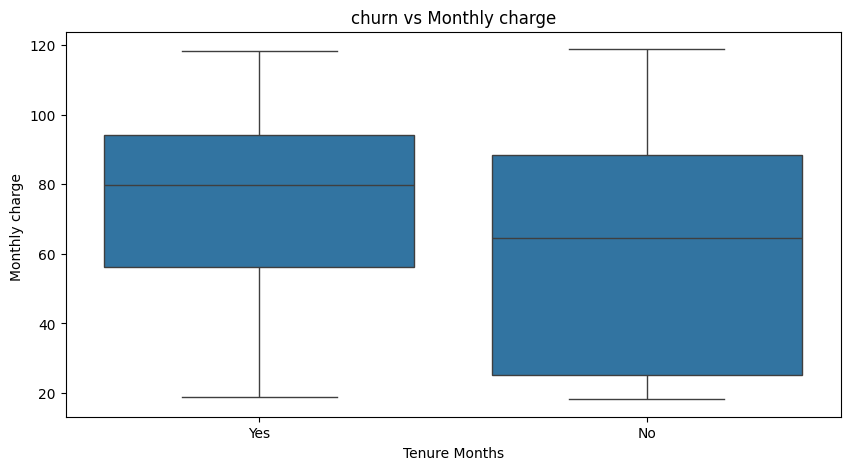

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Monthly Charges',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Monthly charge ')
plt.title('churn vs Monthly charge')
plt.show()

In [14]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [16]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [17]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [18]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [19]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


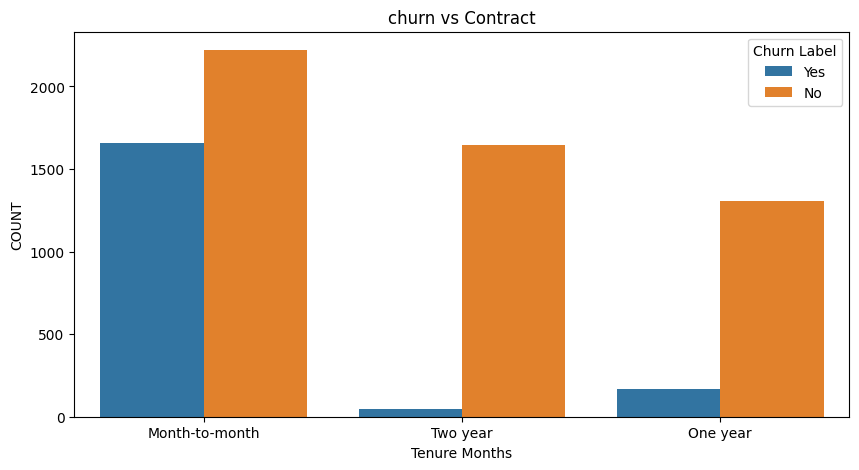

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('COUNT')
plt.title('churn vs Contract')
plt.show()
#month to month have high churn rate

In [21]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

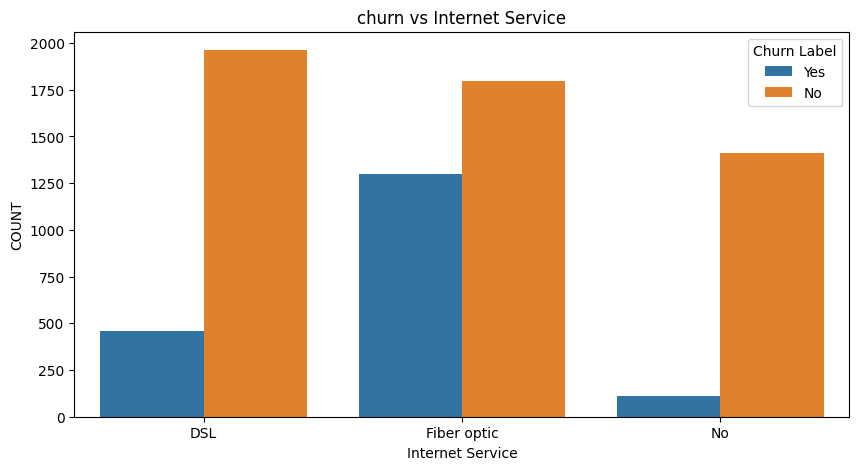

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('COUNT')
plt.title('churn vs Internet Service')
plt.show()
# premiup service have high churn rate

In [23]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

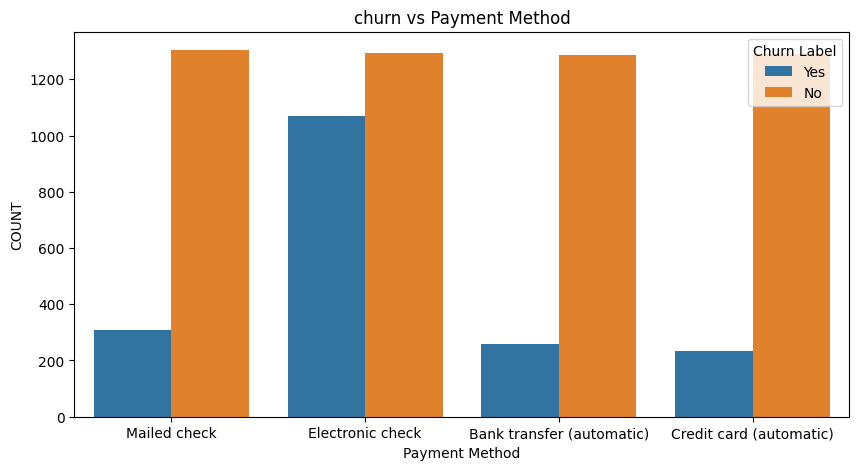

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('COUNT')
plt.title('churn vs Payment Method')
plt.show()
# high churn for electronic check
# inertia automatic -> peopel it will required strong reason for change

In [25]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

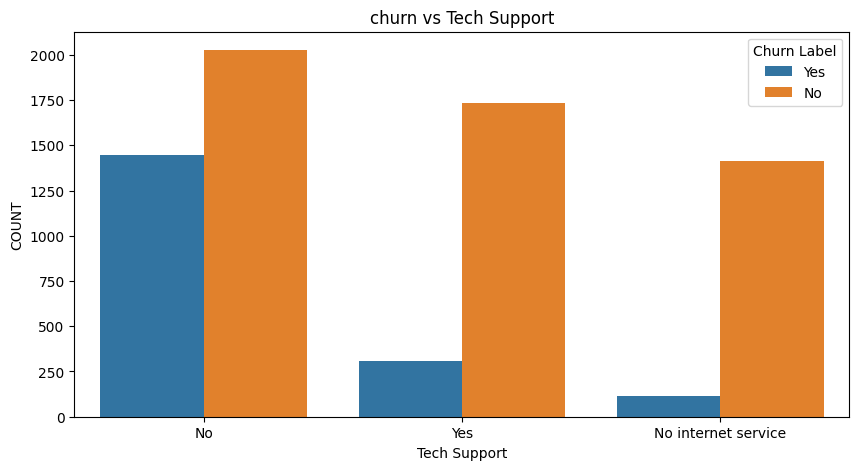

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('COUNT')
plt.title('churn vs Tech Support')
plt.show()

In [27]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [28]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [29]:
num_col=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']

In [30]:
corr_mt=df[num_col].corr()
corr_mt

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


<Axes: >

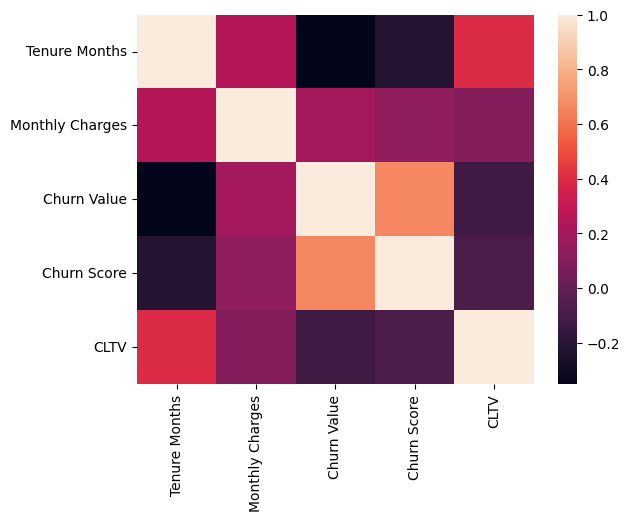

In [31]:

sns.heatmap(corr_mt)

In [32]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'])
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [33]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [34]:
tech_support_churn =pd.crosstab(df['Tech Support'],df['Churn Label'])
tech_support_churn

Churn Label,No,Yes
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


### data cleaning

In [35]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [36]:
df['Total Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5], dtype=object)

In [37]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [39]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [40]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [41]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [42]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [43]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [44]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [45]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
              'Churn Score','CLTV','Churn Reason']

df=df.drop(columns=drop_columns)

In [46]:
df.shape

(7043, 21)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [48]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [49]:
df=df.drop(columns='City')

In [50]:
df_encode=pd.get_dummies(df,drop_first=True)

In [51]:
df_encode.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [52]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [53]:
X=df_encode.drop(columns='Churn Value')
# drop('churn Value,axis=1)
y=df_encode['Churn Value']

In [54]:
X.shape,y.shape

((7043, 30), (7043,))

In [55]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [56]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

# machine learning implementation

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [59]:
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

Random Forest implementation

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
from sklearn.metrics import accuracy_score

In [62]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [63]:
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [64]:
y_pred = rf.predict(X_test)


In [65]:
accuracy = accuracy_score(y_test, y_pred)

In [66]:
print("Accuracy:", accuracy)

Accuracy: 0.7856635911994322


Confusion Matrix

In [67]:
from sklearn.metrics import confusion_matrix


In [68]:
cm = confusion_matrix(y_test, y_pred)

In [69]:
print(cm)


[[902 107]
 [195 205]]


In [70]:
from sklearn.metrics import classification_report

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Apporach - 1 Handle class imbalance

In [72]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(accuracy_balanced, cm_balanced)

print(classification_report(y_test, y_pred_balanced))

0.7920511000709723 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Apporach -2 Hyper parameter tuning

In [73]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



Apporach - 3 Feature importance feauture

In [74]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Freatures' : X.columns,
    'Importance' :rf_tuned.feature_importances_

})
feature_importance =feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                                 Freatures  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [75]:
X_selected = X.drop(['Phone Service_Yes','Multiple Lines_No phone service'], axis=1)
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [76]:
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [77]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [78]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]

results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:

        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append([
            n_trees,
            depth,
            accuracy,
            precision,
            recall,
            f1
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'n_estimators',
        'max_depth',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(results_df)

best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print("\nBest Model:")
print(best_model)

results_df.sort_values(by='F1 Score', ascending=False).head(10)

    n_estimators  max_depth  Accuracy  Precision  Recall  F1 Score
0            100          5  0.745919   0.534202  0.8200  0.646943
1            100         10  0.775727   0.581081  0.7525  0.655773
2            100         15  0.802697   0.659686  0.6300  0.644501
3            100         20  0.787793   0.655385  0.5325  0.587586
4            200          5  0.742370   0.530278  0.8100  0.640950
5            200         10  0.782115   0.592445  0.7450  0.660022
6            200         15  0.804826   0.663185  0.6350  0.648787
7            200         20  0.793471   0.674121  0.5275  0.591865
8            300          5  0.743790   0.531605  0.8200  0.645034
9            300         10  0.782825   0.593254  0.7475  0.661504
10           300         15  0.806246   0.664935  0.6400  0.652229
11           300         20  0.787793   0.658307  0.5250  0.584145
12           400          5  0.743790   0.531915  0.8125  0.642928
13           400         10  0.782825   0.593254  0.7475  0.66

,n_estimators,max_depth,Accuracy,Precision,Recall,F1 Score
13,400,10,0.782825,0.593254,0.7475,0.661504
9,300,10,0.782825,0.593254,0.7475,0.661504
17,500,10,0.781405,0.590909,0.7475,0.660044
5,200,10,0.782115,0.592445,0.7450,0.660022
1,100,10,0.775727,0.581081,0.7525,0.655773
10,300,15,0.806246,0.664935,0.6400,0.652229
6,200,15,0.804826,0.663185,0.6350,0.648787
14,400,15,0.803407,0.658915,0.6375,0.648030
0,100,5,0.745919,0.534202,0.8200,0.646943
18,500,15,0.801987,0.655527,0.6375,0.646388


CROSS_VEL_SCORE

In [79]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
cv_accuracy = cross_val_score(
    final_rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Accuracy Scores:", cv_accuracy)

Cross Validation Accuracy Scores: [0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]


In [80]:
print("Mean CV Accuracy:", cv_accuracy.mean())

Mean CV Accuracy: 0.7793569343183432


In [81]:
cv_recall = cross_val_score(final_rf, X, y, cv=5, scoring='recall')
print("Recall Scores:", cv_recall)

Recall Scores: [0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]


In [82]:
print("Mean Recall:", cv_recall.mean())

Mean Recall: 0.7335350030823931


ROC CURVE

ROC-AUC Score: 0.857104806739346


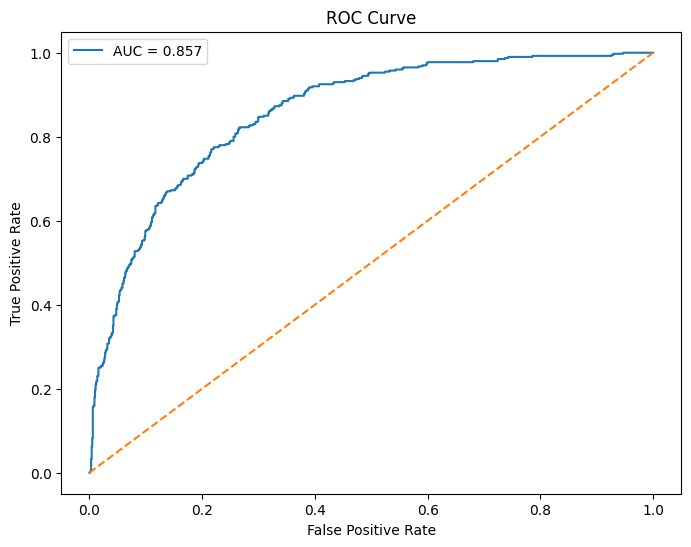

In [83]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = rf_tuned.predict_proba(X_test)

churn_prob = y_prob[:, 1]

fpr, tpr, threshold = roc_curve(y_test, churn_prob)

auc_score = roc_auc_score(y_test, churn_prob)

print("ROC-AUC Score:", auc_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

CUSTOMER SEGMENTATION

In [84]:
segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges']
})
segmentation_data.head()
print(X.columns)

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Gender_Male',
       'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')


IMPLEMENTATION OF KMEANS

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(segmentation_data)

In [86]:
from sklearn.cluster import KMeans

scaled_data = scaler.fit_transform(segmentation_data)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_data)

clusters = kmeans.labels_

segmentation_data['Cluster'] = clusters

print(segmentation_data.head())

   Tenure Months  Monthly Charges  Total Charges  Cluster
0              2            53.85         108.15        3
1              2            70.70         151.65        1
2              8            99.65         820.50        1
3             28           104.80        3046.05        4
4             49           103.70        5036.30        2


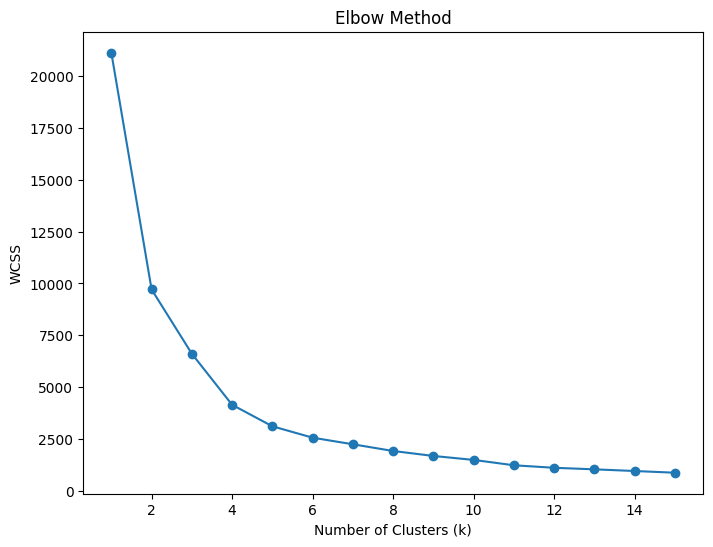

In [87]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

print(clusters)

[1 1 1 ... 2 1 2]


In [89]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
0    Male             No      No         No              2           Yes   
1  Female             No      No        Yes              2           Yes   
2  Female             No      No        Yes              8           Yes   
3  Female             No     Yes        Yes             28           Yes   
4    Male             No      No        Yes             49           Yes   

  Multiple Lines Internet Service Online Security Online Backup  ...  \
0             No              DSL             Yes           Yes  ...   
1             No      Fiber optic              No            No  ...   
2            Yes      Fiber optic              No            No  ...   
3            Yes      Fiber optic              No            No  ...   
4            Yes      Fiber optic              No           Yes  ...   

  Tech Support Streaming TV Streaming Movies        Contract  \
0           No           No               No  

In [90]:
segmentation_data['Cluster'] = clusters

In [91]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Cluster
0,2,53.85,108.15,1
1,2,70.70,151.65,1
2,8,99.65,820.50,1
3,28,104.80,3046.05,2
4,49,103.70,5036.30,2
...,...,...,...,...
7038,72,21.15,1419.40,0
7039,24,84.80,1990.50,1
7040,72,103.20,7362.90,2
7041,11,29.60,346.45,1


In [94]:
cluster_summary = segmentation_data.groupby('Cluster').mean()

In [95]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges
Cluster,,,
0,44.407458,29.657390,1343.367559
1,10.715394,62.477879,746.685621
2,57.116877,91.582175,5221.936530


In [96]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}

segmentation_data['Segment'] = segmentation_data['Cluster'].map(cluster_names)

segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Cluster,Segment
0,2,53.85,108.15,1,High Risk New Customers
1,2,70.70,151.65,1,High Risk New Customers
2,8,99.65,820.50,1,High Risk New Customers
3,28,104.80,3046.05,2,Loyal Premium Customers
4,49,103.70,5036.30,2,Loyal Premium Customers


In [101]:
print(segmentation_data.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Cluster', 'Segment']


In [102]:
print(segmentation_data.head())

   Tenure Months  Monthly Charges  Total Charges  Cluster  \
0              2            53.85         108.15        1   
1              2            70.70         151.65        1   
2              8            99.65         820.50        1   
3             28           104.80        3046.05        2   
4             49           103.70        5036.30        2   

                   Segment  
0  High Risk New Customers  
1  High Risk New Customers  
2  High Risk New Customers  
3  Loyal Premium Customers  
4  Loyal Premium Customers  


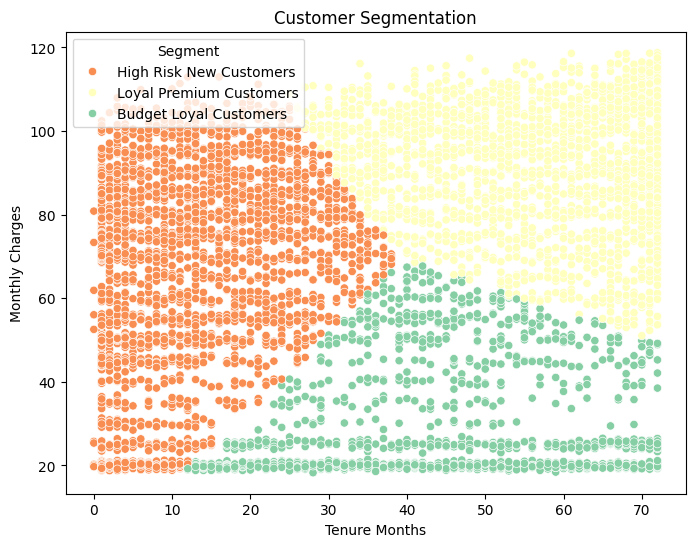

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.title('Customer Segmentation')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.legend(title='Segment')
plt.show()

In [105]:
segmentation_data['Churn Probability'] = (
    1 - segmentation_data['Tenure Months'] /
    segmentation_data['Tenure Months'].max()
)

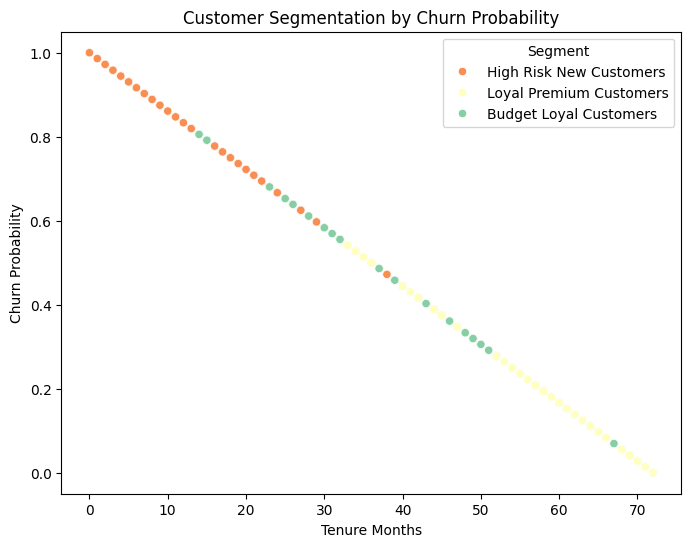

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=segmentation_data,
    x='Tenure Months',
    y='Churn Probability',
    hue='Segment',
    palette='Spectral'
)

plt.title('Customer Segmentation by Churn Probability')
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.legend(title='Segment')

plt.show()